In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math
import numpy.random as random

# アーラン分布

確率密度関数 ($x$は正の実数、$y$は正の整数)

$$ f(k; x,y) = \frac{x^{y}}{(y-1)!}k^{y-1}e^{-xk}$$

累積分布関数

$$ F(k; x,y) = \int_{0}^{k} f(k; x,y) dk $$

$$ F(k; x,y) = 1 - e^{-xk}\sum_{n=0}^{y-1}\frac{(xk)^{n}}{n!}$$

パラメータ x,y のアーラン分布の確率密度関数のplot

In [4]:
def erlang_pdfplot(x,y):
    k = np.linspace(0,100,10001)
    p = []
    
    for j in k:
        pdf = ((x**y)/math.factorial(y-1))*(j**(y-1))*np.exp(-x*j)
        p.append(pdf)
    
    
    plt.plot(k,p)
    plt.xlabel("k")
    plt.ylabel("Probability density")
    plt.title("P(x = k) : Probability density function")
    plt.show()
    

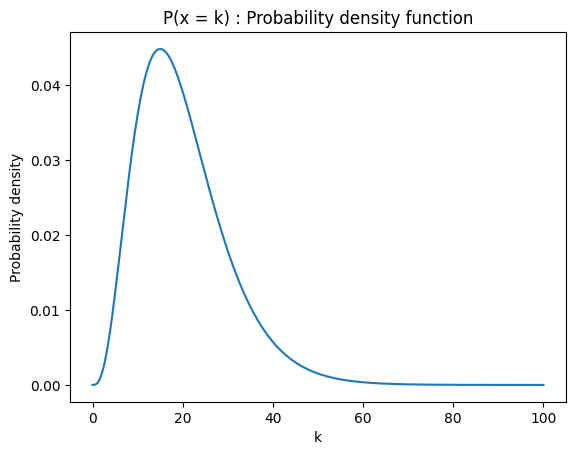

In [5]:
erlang_pdfplot(0.2,4)

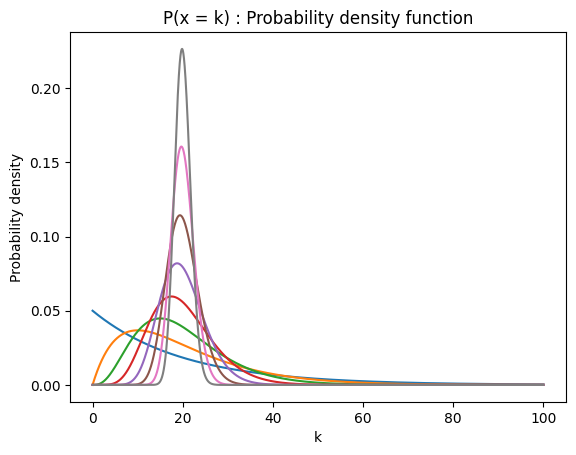

In [ ]:
# report:問題1

for i in range(8):
    y = 2 ** i
    x = y / 20 
    k = np.linspace(0,100,10001)
    p = []
    
    for j in k:
        pdf = ((x**y)/math.factorial(y-1))*(j**(y-1))*np.exp(-x*j)
        p.append(pdf)
    
    
    plt.plot(k,p)

plt.xlabel("k")
plt.ylabel("Probability density")
plt.title("P(x = k) : Probability density function")
plt.show()

パラメータ x,y のアーラン分布の累積分布関数のplot

In [ ]:


def erlang_cdfplot(x,y):
    k = np.linspace(0,100,10001)
    p = []
    cdf = 0
    for j in k:
        cdf += ((x**y)/math.factorial(y-1))*(j**(y-1))*np.exp(-x*j)
        p.append(cdf)
    
    
    plt.plot(k,p)
    plt.xlabel("k")
    plt.ylabel("Cumulative distirbution")
    plt.title("P(x <= k) : Cumulative distirbution function")
    plt.show()
    

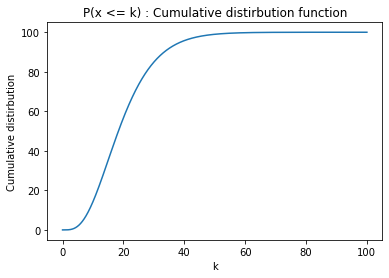

In [43]:
erlang_cdfplot(0.2,4)

## シミュレーション

### パラメータ x,y のアーラン分布に従う乱数を発生させる関数

In [18]:
#逆関数法による指数乱数の発生
def exp(x):
    y = random.random()
    X = -math.log(y)/x
    return X

In [19]:
def erlang(x,y): 
    X = 0
    for i in range(y):
        X += exp(x)
    return X

In [ ]:
### パラメータ lam の指数分布に従う到着間隔, パラメータ x,y のアーラン分布に従うサービス時間を持つ待ち行列モデル
### 到着の指数分布のパラメータlam, サービスのパラメータ x,y を　与えて平均系内人数と平均系内時間のリストを返す関数
def simulation_mg1_erlang(lam,x,y):
    j = 0 #系内人数
    j_before = 0 #計算用の系内人数
    time = 0 #時間
    time_include = 0 #実際の性能評価指標の計算に用いる時間
    interval = 0 #イベントの間隔
    cum_visitor = 0 #累積系内人数
    cum_visitor_before = 0 #計算から除外する累積系内人数
    sojourn_time = list() #系内時間記録用リスト
    arrive_time = list() #到着時間記録用リスト
    finish_time = list() #サービス終了時刻記録用リスト
    numerator_EL_sim=0 #平均系内客数の計算に利用(これを時間:time_includeで割り算する)
    residual = 0 #残余サービス時間
    
    Nt_list = [] #eventが発生した時刻の系内人数(離散値)
    event_time = [] #eventが発生した時刻
    

    for state in range(110000):
        j_before = j
        if j==0: #系内人数が0のとき:到着しか起こらない
            j += 1
            interval = exp(lam)
            cum_visitor += 1
            arrive_time.append(time + interval)
            residual = erlang(x,y)
        elif j==1:
            a = exp(lam)
            b = residual
            if a==min(a,b): #到着
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                residual -= interval #到着が起きたときは到着間隔だけ残余サービス時間が減少する
            else: #サービス完了
                j -= 1
                interval = b
                finish_time.append(time + interval)
                residual = 0
                #系内人数が0になってj==0のブロックに移るため, 形式的に0を代入(比較処理が発生しないため何でも良い)
        else:
            a = exp(lam)
            b = residual
            if a==min(a,b): #到着
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                residual -= interval #到着が起きたときは到着間隔だけ残余サービス時間が減少する
            else: #サービス完了
                j -= 1
                interval = b
                finish_time.append(time + interval)
                residual = erlang(x,y)
                #サービスが完了し, 次の客のサービス時間として残余サービス時間の再生が起こる      
        if state==10000:
            cum_visitor_before = cum_visitor
        if state>10000:
            time_include += interval
            numerator_EL_sim += interval*j_before
            Nt_list.append(j)
            event_time.append(time_include)
        time += interval
        

    ###性能評価指標の計算  
    #平均系内客数
    EL_sim = numerator_EL_sim/time_include
    #平均系内時間
    for i in range(cum_visitor_before-1,len(finish_time)):
        sojourn_time.append(finish_time[i]-arrive_time[i])
    

    return EL_sim, Nt_list, event_time, sojourn_time


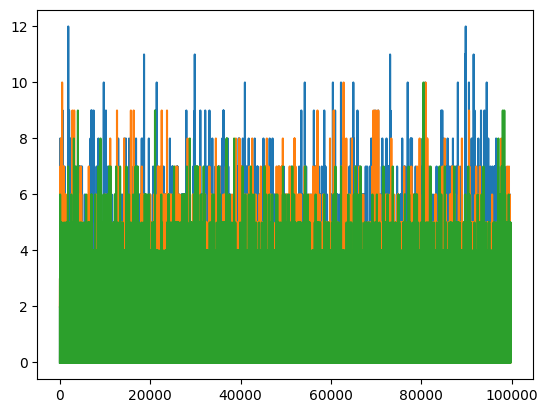

In [37]:
# report:問題2
for i in range(3):
    y = 2 ** i
    x = y
    MG1_EL_sim, MG1_Nt_list,MG1_event_time, MG1_sojourn_time = simulation_mg1_erlang(0.5,x,y)

    plt.plot(MG1_event_time,MG1_Nt_list)

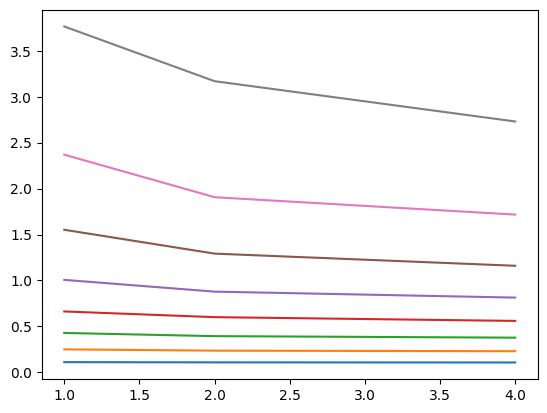

In [61]:
# report:問題3

for p in range(1,9):
    lam = p * 0.1
    EL_list = []
    shapes = []
    for i in range(3):
        y = 2 ** i
        x = y
        MG1_EL_sim, MG1_Nt_list, MG1_event_time, MG1_sojourn_time = simulation_mg1_erlang(lam,x,y)
        EL_list.append(MG1_EL_sim)
        shapes.append(x)
    
    plt.plot(shapes,EL_list)

plt.show()

In [ ]:
#report:問題6
#TODO:シミュレーションとして正しいはずだが変数名などが間違ってる気がするので直す必要がある

### パラメータ lam の指数分布に従う到着間隔, パラメータ x,y のアーラン分布に従うサービス時間を持つ待ち行列モデル
### 到着の指数分布のパラメータlam, サービスのパラメータ x,y を　与えて平均系内人数と平均系内時間のリストを返す関数
def simulation_gm1_erlang(lam,x,y):
    j = 0 #系内人数
    j_before = 0 #計算用の系内人数
    time = 0 #時間
    time_include = 0 #実際の性能評価指標の計算に用いる時間
    interval = 0 #イベントの間隔
    cum_visitor = 0 #累積系内人数
    cum_visitor_before = 0 #計算から除外する累積系内人数
    sojourn_time = list() #系内時間記録用リスト
    arrive_time = list() #到着時間記録用リスト
    finish_time = list() #サービス終了時刻記録用リスト
    numerator_EL_sim=0 #平均系内客数の計算に利用(これを時間:time_includeで割り算する)
    residual = 0 #残余サービス時間
    
    Nt_list = [] #eventが発生した時刻の系内人数(離散値)
    event_time = [] #eventが発生した時刻
    

    for state in range(110000):
        j_before = j
        
        if j==0: #系内人数が0のとき:到着しか起こらない
            j += 1
            interval = erlang(x,y)
            cum_visitor += 1
            arrive_time.append(time + interval)
            residual = exp(lam)
            
        # j > 0のとき,residualの処理のみがj == 1のとき変わるのでresidualの処理のみ変えれば良い
        #elif j==1:
        #    a = erlang(x,y)
        #    b = residual
        #    if a <= b: #到着
        #        j += 1
        #        interval = a
        #        cum_visitor += 1
        #        arrive_time.append(time + interval)
        #        residual -= interval #到着が起きたときは到着間隔だけ残余サービス時間が減少する
        #    else: #サービス完了
        #        j -= 1
        #        interval = b
        #        finish_time.append(time + interval)
        #        residual = 0
        #        #系内人数が0になってj==0のブロックに移るため, 形式的に0を代入(比較処理が発生しないため何でも良い)
        else:
            a = erlang(x,y)
            b = residual
            if a <= b: #到着
                j += 1
                interval = a
                cum_visitor += 1
                arrive_time.append(time + interval)
                residual -= interval #到着が起きたときは到着間隔だけ残余サービス時間が減少する
            else: #サービス完了
                j -= 1
                interval = b
                finish_time.append(time + interval)
                residual = 0 if j == 0 else  erlang(x,y)
                #サービスが完了し, 次の客のサービス時間として残余サービス時間の再生が起こる      
        if state==10000:
            cum_visitor_before = cum_visitor
        if state>10000:
            time_include += interval
            numerator_EL_sim += interval*j_before
            Nt_list.append(j)
            event_time.append(time_include)
        time += interval
        

    ###性能評価指標の計算  
    #平均系内客数
    EL_sim = numerator_EL_sim/time_include
    #平均系内時間
    for i in range(cum_visitor_before-1,len(finish_time)):
        sojourn_time.append(finish_time[i]-arrive_time[i])
    

    return EL_sim, Nt_list, event_time, sojourn_time


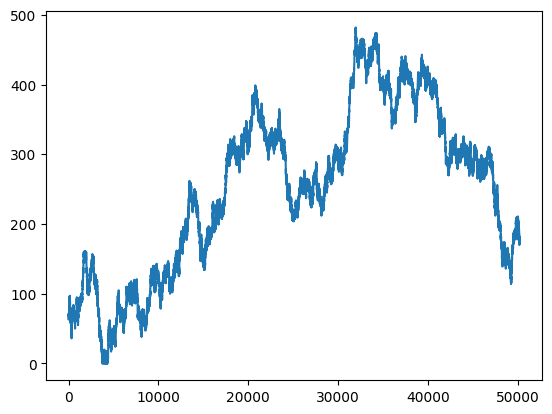

In [168]:
MG1_EL_sim, MG1_Nt_list, MG1_event_time, MG1_sojourn_time = simulation_gm1_erlang(1.0,1,1)

plt.plot(MG1_event_time,MG1_Nt_list)

In [ ]:
#report:問題6
#TODO:シミュレーションとして正しいはずだが変数名などが間違ってる気がするので直す必要がある

### パラメータ lam の指数分布に従う到着間隔, パラメータ x,y のアーラン分布に従うサービス時間を持つ待ち行列モデル
### 到着の指数分布のパラメータlam, サービスのパラメータ x,y を　与えて平均系内人数と平均系内時間のリストを返す関数
def simulation_gm1_erlang(lam,x,y):
    j = 0 #系内人数
    j_before = 0 #計算用の系内人数
    time = 0 #時間
    time_include = 0 #実際の性能評価指標の計算に用いる時間
    interval = 0 #イベントの間隔 
    cum_visitor = 0 #累積系内人数
    cum_visitor_before = 0 #計算から除外する累積系内人数
    sojourn_time = list() #系内時間記録用リスト
    arrive_time = list() #到着時間記録用リスト
    finish_time = list() #サービス終了時刻記録用リスト
    numerator_EL_sim=0 #平均系内客数の計算に利用(これを時間:time_includeで割り算する)
    residual = 0 #残余サービス時間
    next_arrive_time = erlang(x,y)
    
    Nt_list = [] #eventが発生した時刻の系内人数(離散値)
    event_time = [] #eventが発生した時刻
    

    for state in range(110000):
        j_before = j
        # 到着
        if j == 0 or residual > next_arrive_time:
            j += 1
            cum_visitor += 1
            interval = next_arrive_time
            
            arrive_time.append(time + interval)
            
            residual = exp(lam) if j == 1 else residual - interval
            next_arrive_time = erlang(x,y)
            
        # 出発
        else :
            #出発処理
            j -= 1
            cum_visitor -= 1
            interval  = residual
            
            #記録
            finish_time.append(time + interval)
            
            #次
            residual = exp(lam)
            next_arrive_time -= interval
            
        
        
        if state==10000:
            cum_visitor_before = cum_visitor
        if state>10000:
            time_include += interval
            numerator_EL_sim += interval*j_before
            Nt_list.append(j)
            event_time.append(time_include)
        time += interval
        

    ###性能評価指標の計算  
    #平均系内客数
    EL_sim = numerator_EL_sim/time_include
    #平均系内時間
    for i in range(cum_visitor_before-1,len(finish_time)):
        sojourn_time.append(finish_time[i]-arrive_time[i])
    

    return EL_sim, Nt_list, event_time, sojourn_time
